In [ ]:
# Pastikan semua dependensi yang dibutuhkan tersedia di kernel Jupyter.
%pip install --quiet numpy matplotlib sympy plotly

In [ ]:
%matplotlib inline

# Komputasi Superposisi Gaya Listrik
Notebook ini menghitung gaya superposisi dari beberapa muatan terhadap satu muatan uji di titik asal (0,0,0) berdasarkan Hukum Coulomb, lalu memvisualisasikan modelnya ke dalam plot 3D.

--- Perhitungan Gaya Superposisi ---
Gaya dari q1 (2 µC) terhadap q: [ 0.    -0.045  0.   ] N
Gaya dari q2 (4 µC) terhadap q: [-0.03181981 -0.03181981  0.        ] N
Gaya dari q3 (5 µC) terhadap q: [ 0.         -0.03977476 -0.03977476] N
Gaya dari q4 (-5 µC) terhadap q: [0.02165064 0.02165064 0.02165064] N
----------------------------------------
Vektor Gaya Total (F_total): [-0.01016917 -0.09494393 -0.01812412] N
Besar Gaya Total (|F_total|): 0.0972 N


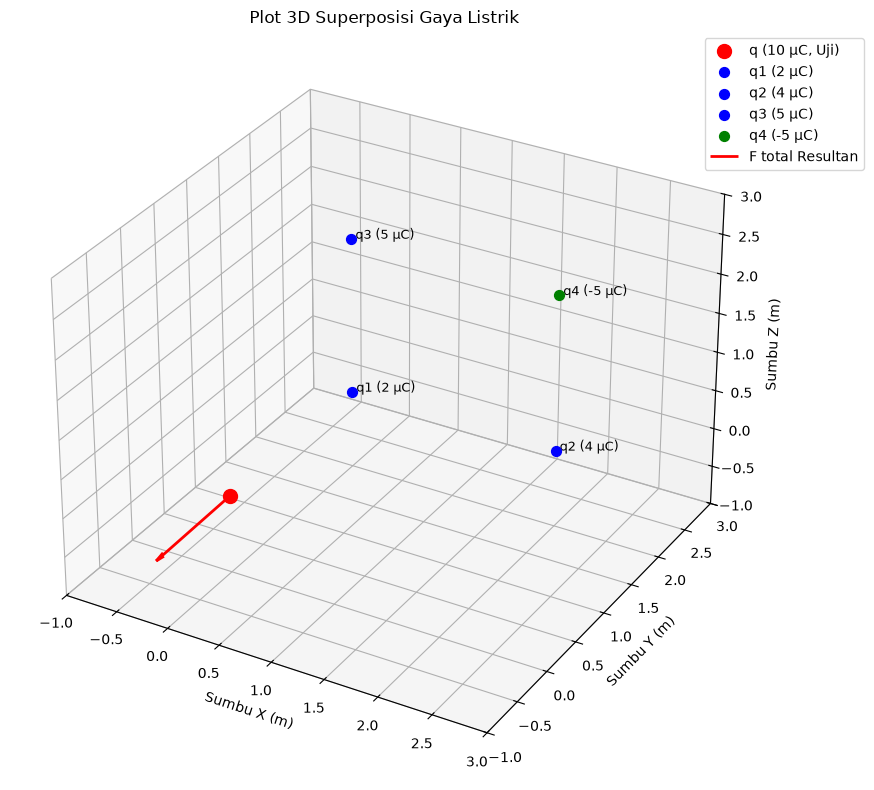

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def hitung_superposisi_gaya():
    # Konstanta Coulomb (N m^2 / C^2)
    k = 9e9
    
    # Muatan uji q di titik asal (0,0,0) dalam Coulomb
    q = 10e-6 
    r_q = np.array([0.0, 0.0, 0.0])
    
    # Data muatan sumber (q_i dalam Coulomb, posisi dalam meter)
    muatan_sumber = [
        {'q': 2e-6,  'pos': np.array([0.0, 2.0, 0.0]), 'label': 'q1 (2 µC)'},
        {'q': 4e-6,  'pos': np.array([2.0, 2.0, 0.0]), 'label': 'q2 (4 µC)'},
        {'q': 5e-6,  'pos': np.array([0.0, 2.0, 2.0]), 'label': 'q3 (5 µC)'},
        {'q': -5e-6, 'pos': np.array([2.0, 2.0, 2.0]), 'label': 'q4 (-5 µC)'}
    ]
    
    # Vektor gaya total
    F_total = np.zeros(3)
    
    print("--- Perhitungan Gaya Superposisi ---")
    for i, muatan in enumerate(muatan_sumber):
        r_i = muatan['pos']
        q_i = muatan['q']
        
        # Vektor jarak dari sumber ke muatan uji
        r_vec = r_q - r_i
        r_mag = np.linalg.norm(r_vec)
        
        # Menghitung gaya Coulomb dari muatan i: F_i = k * q * q_i * (r_vec / r_mag^3)
        F_i = k * q * q_i * (r_vec / (r_mag**3))
        F_total += F_i
        
        print(f"Gaya dari {muatan['label']} terhadap q: {F_i} N")
        
    print("-" * 40)
    print(f"Vektor Gaya Total (F_total): {F_total} N")
    print(f"Besar Gaya Total (|F_total|): {np.linalg.norm(F_total):.4f} N")
    
    return muatan_sumber, r_q, F_total

def plot_model_3d(muatan_sumber, r_q, F_total):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot muatan uji q
    ax.scatter(*r_q, color='red', s=100, label='q (10 µC, Uji)', marker='o')
    
    # Plot muatan sumber
    for muatan in muatan_sumber:
        pos = muatan['pos']
        warna = 'blue' if muatan['q'] > 0 else 'green'
        ax.scatter(*pos, color=warna, s=50, label=muatan['label'])
        ax.text(pos[0], pos[1], pos[2], f" {muatan['label']}", size=9, zorder=1, color='k')
    
    # Plot Vektor Gaya Total (F_total)
    skala_visual = 1.0 / (np.linalg.norm(F_total) + 1e-9)
    ax.quiver(*r_q, *(F_total * skala_visual), color='red', linewidth=2, 
              arrow_length_ratio=0.1, label='F total Resultan')
    
    # Konfigurasi plot
    ax.set_xlabel('Sumbu X (m)')
    ax.set_ylabel('Sumbu Y (m)')
    ax.set_zlabel('Sumbu Z (m)')
    ax.set_title('Plot 3D Superposisi Gaya Listrik')
    
    ax.set_xlim([-1, 3])
    ax.set_ylim([-1, 3])
    ax.set_zlim([-1, 3])
    
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    # Menggunakan plt.show() agar plot langsung tampil di Jupyter Notebook
    plt.show()

muatan_sumber, r_q, F_total = hitung_superposisi_gaya()
plot_model_3d(muatan_sumber, r_q, F_total)